# PGMST — Florida demo (`PGNN` + `MST`)

Same inputs as `notebook/SGCN_MST_IJGIS_2025-V01.ipynb`:

1. **`pgmst.pgnn.PGNN`** — packaged **SGCN** pipeline (half-life OD + spatial glue `w_adj`). `embed()` appends **`Emb_X` / `Emb_Y`**. Pass **`coordxy="XCoord,YCoord"`** to use existing coordinate columns; if omitted, **`geometry.centroid`** fills `XCoord`/`YCoord`. Contiguity: **`w="queen"` / `"rook"`** or **`focal`/`neighbor`** table (here **`FLAdjUpdate.csv`**).
2. **`pgmst.mst.MST`** — spatial **adjacency** ``w`` + **embedding** distances define the MST; **OD** + **`constraints`** `(column, "min"|"max", value)` drive DFS / cuts (no planar XY here). Population column **inferred** when a column has both min and max. **`partition()`** → **`.cluster`**, **`.result`**, **`.modularity`**.
3. **Optional GCN** — a separate code cell below imports PyTorch / `physics_graph` and runs a small **GCN** + **`MST`** (not needed for the main **PGNN** path).

This notebook does **not** include loading embeddings from external CSVs; only **PGNN** or the explicit **GCN** block + **MST**.

In [1]:
from pathlib import Path
import os

import pgmst
import pandas as pd
import geopandas as gpd

from pgmst import PGNN, MST

# Installed/editable package lives in …/PGMST/pgmst/ → repo root is parent
_pkg = Path(pgmst.__file__).resolve().parent
PGMST_ROOT = _pkg.parent
if not (PGMST_ROOT / "pyproject.toml").is_file():
    PGMST_ROOT = Path.cwd().resolve()
print("PGMST_ROOT:", PGMST_ROOT)

C:\Users\lil928\AppData\Roaming\Python\Python39\site-packages\networkx\utils\backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


PGMST_ROOT: D:\GitHub\PGMST


## Data paths (same inputs as the IJGIS notebook)

Data files are **not** resolved from the string `"examples\\..."` relative to nothing useful — they must be **absolute** or anchored to a known root.

- Default: `REPO = PGMST_ROOT.parent` (clone **GNNGeoCommunity** next to **PGMST** so `../data/` matches the IJGIS notebook).
- Or set env **`PGMST_DATA_REPO`** to the folder that contains a `data/` subfolder with the three files.
- Or put copies under **`PGMST/examples/data/`** (all three in the same folder).

In [2]:
# Prefer sibling GNNGeoCommunity repo: …/GNNGeoCommunity/data/ (same as IJGIS notebook)
REPO = Path(os.environ.get("PGMST_DATA_REPO", PGMST_ROOT.parent))
data_dir = REPO / "data"
if not (data_dir / "OD_All_Flows30K.csv").is_file():
    alt = PGMST_ROOT / "examples" / "data"
    if (alt / "OD_All_Flows30K.csv").is_file():
        data_dir = alt
    else:
        raise FileNotFoundError(
            f"Expected OD/zip under {data_dir} or {alt}. "
            "Clone GNNGeoCommunity beside PGMST, or set env PGMST_DATA_REPO to the repo root that contains data/."
        )

flowpth = data_dir / "OD_All_Flows30K.csv"
adjpth = data_dir / "FLAdjUpdate.csv"
coordf = data_dir / "Florida_2011.zip"

df_flow = pd.read_csv(flowpth)
df_adj = pd.read_csv(adjpth)
coords_df = gpd.read_file(coordf)

coords_df.head(2)

,ZoneID,XCoord,YCoord,POPU,hosp,POPUDen,geometry
0,1,-82.360933,27.712743,19172,1,400.105294,"POLYGON ((-82.3849 27.71279, -82.38447 27.7138..."
1,2,-82.309107,28.322751,3784,0,91.505380,"POLYGON ((-82.30752 28.34294, -82.30758 28.342..."


## Step 1–2 — `PGNN` (SGCN) + `MST` (paper-style: `FLAdjUpdate` contiguity)

In [3]:
# Same spatial graph as §2–1 / §3–1: contiguity from FLAdjUpdate.csv (not Queen/Rook)
# coordxy: use existing X/Y columns (paper-style). Omit coordxy to use geometry.centroid instead.
pgnn = PGNN(
    coords_df,
    df_flow,
    id_column="ZoneID",
    w=df_adj,
    k_hops=5,
    w_adj_percentile=75.0,
    coordxy="XCoord,YCoord",
)
coords_emb = pgnn.embed(embed_x_col="Emb_X", embed_y_col="Emb_Y")

In [4]:
# Uses coords_emb from previous cell. Population column for split/caps is inferred
# from constraints when a column has both "min" and "max" (here: POPU).
mst_solver = MST(
    coords_emb,
    df_flow,
    id_column="ZoneID",
    emb=("Emb_X", "Emb_Y"),
    w=df_adj,
    constraints=[
        ("POPU", "min", 10_000),
        ("POPU", "max", 500_000),
        ("hosp", "min", 1),
    ],
    min_local_index=0.3,
    cluster_column_name="cluster",
)
pr = mst_solver.partition()

pr.cluster[["ZoneID", "Emb_X", "Emb_Y", "cluster"]].head()

,ZoneID,Emb_X,Emb_Y,cluster
0,1,-0.328205,-0.264434,20
1,2,-0.152745,0.018020,100
2,3,-0.186657,-0.103962,93
3,4,-0.180488,-0.124795,93
4,5,-0.167122,-0.081637,100


In [5]:
n_comm = pr.cluster["cluster"].nunique()
print("Communities:", int(n_comm), "  Total modularity:", round(pr.modularity, 6))
pr.result.head(3)

Communities: 101   Total modularity: 0.521361


,cluster,n_zones,Comm_LI,Comm_Pop,Comm_Hosp,POPU_sum,POPU_min,POPU_max,hosp_sum,hosp_min,hosp_max,reock,polsby_popper,geometry
0,0,3,0.735866,43033.0,1.0,43033.0,4313.0,32891.0,1.0,0.0,1.0,0.315160,0.093489,"MULTIPOLYGON (((-81.6553 24.62542, -81.65336 2..."
1,1,3,0.317445,10033.0,1.0,10033.0,315.0,8944.0,1.0,0.0,1.0,0.615135,0.186483,"POLYGON ((-80.92866 24.79154, -80.91193 24.802..."
2,2,1,0.666667,11457.0,1.0,11457.0,11457.0,11457.0,1.0,1.0,1.0,0.760624,0.279901,"POLYGON ((-86.31003 30.37747, -86.30996 30.377..."


<Axes: >

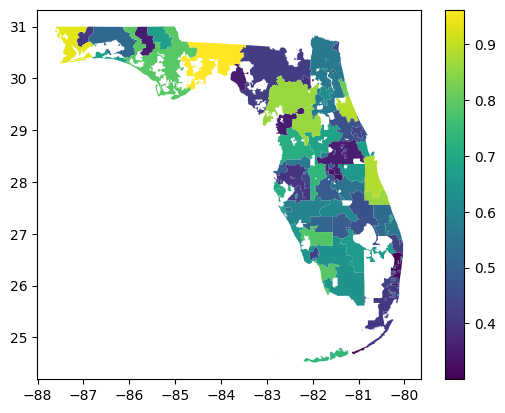

In [6]:
pr.result.plot(column='Comm_LI',legend=True)

## Optional: **GCN** in this notebook + same `MST`

`PGNN` wraps **SGCN** only. For a **GCN–MST**-style comparison, the code cell below imports **PyTorch / PyG** and **`pgmst.physics_graph`** locally (the setup cell above only needs **PGNN** + **MST**). It builds the same flow + spatial graph tensors (`compute_w_flow_nonzero`, `prepare_graph_tensors`, `node_feature_matrix`), runs a **two-layer `GCNConv`** (random init, no training — add a training loop if you use a learned GNN), merges **`Emb_X` / `Emb_Y`**, then calls **`MST`** with the same constraints as above.

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

from pgmst.coords_prep import prepare_coords_table
from pgmst.physics_graph import compute_w_flow_nonzero, prepare_graph_tensors, node_feature_matrix
from pgmst.utils import resolve_hospital_column

# Same physics-informed graph as PGNN / paper §2–1 (half-life OD + w_adj on spatial edges)
internal = prepare_coords_table(coords_df, id_col="ZoneID", coordxy="XCoord,YCoord")
w_flow, node_mapping, nodes_arr = compute_w_flow_nonzero(internal, df_flow)
if w_flow is None:
    raise RuntimeError("No positive flow edges after matching OD to zones.")
w_adj = float(np.percentile(w_flow, 75))
num_nodes = len(nodes_arr)
edge_index, edge_weight, coords_use = prepare_graph_tensors(
    internal, df_flow, df_adj, w_adj, num_nodes, node_mapping
)
try:
    hosp_col = resolve_hospital_column(coords_use)
except KeyError:
    hosp_col = "hosp"
x_np = node_feature_matrix(coords_use, df_flow, node_mapping, num_nodes, "coords", hosp_col)
x = torch.tensor(x_np, dtype=torch.float)

# Full GCN (PyG) — extend with training loop / checkpoint if you use a learned GNN
torch.manual_seed(42)
in_ch, hidden = x.shape[1], 16


class GCNEmbed(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, 2)

    def forward(self, x_in, ei, ew):
        h = F.relu(self.conv1(x_in, ei, ew))
        return self.conv2(h, ei, ew)


gcn = GCNEmbed().eval()
with torch.no_grad():
    z = gcn(x, edge_index, edge_weight)

rev = {i: zid for zid, i in node_mapping.items()}
emb_gcn_df = pd.DataFrame(
    {
        "ZoneID": [rev[i] for i in range(num_nodes)],
        "Emb_X": z[:, 0].numpy(),
        "Emb_Y": z[:, 1].numpy(),
    }
)
coords_gcn = internal.merge(emb_gcn_df, on="ZoneID", how="left")

mst_gcn = MST(
    coords_gcn,
    df_flow,
    id_column="ZoneID",
    emb=("Emb_X", "Emb_Y"),
    w=df_adj,
    constraints=[("POPU", "min", 10_000), ("POPU", "max", 500_000), ("hosp", "min", 1)],
    min_local_index=0.3,
)
pr_gcn = mst_gcn.partition()
print(pr_gcn.cluster["cluster"].nunique(), "communities (GCN in-notebook + MST)")

103 communities (GCN in-notebook + MST)


<Axes: >

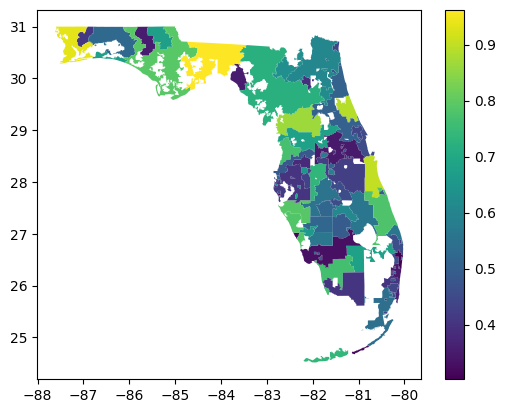

In [8]:
pr_gcn.result.plot(column='Comm_LI',legend=True)